In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# univariate exponential distribution
def exponential_distribution(parameter, x):
    # This version handles arrays/matrices
    return np.where(x >= 0, parameter * np.exp(-parameter * x), 0)

# Values for x=[1, 2] with lambda=1
print(exponential_distribution(1.0, np.array([1, 2])))


[0.36787944 0.13533528]


In [17]:
# INVERSE CDF OF EXPONENTIAL DISTRIBUTION
def inverse_cdf(parameter, p):
    assert parameter > 0 
    assert (p > 0 and  p<1)
    return -1*np.log(p)/parameter # 1-p is also unifrom

print(inverse_cdf(1,0.4))

0.916290731874155


In [32]:
# inverse Transform sampling
def its(parameter):
    # Get a uniform random sampler  U (0,1)
    random_number = np.random.uniform(low=0, high=1)

    # apply inverse cdf of required distribution that we want a sample from
    x = inverse_cdf(parameter, random_number)

    return x


In [50]:
# sample n instances 
i = 0
n = 10000
samples = []
parameter = 2.0
while i < n:
    x = its(parameter)
    samples.append(x)
    i += 1

In [51]:
# mean and variance 
mean = np.mean(samples)
variance = np.var(samples)

print(f" mean, var: {mean}, {variance} ")


# true 
mean_true = 1/parameter
variance_true = 1/ (parameter*parameter)

print(f"True mean, True var: {mean_true}, {variance_true} ")

 mean, var: 0.4975507465668877, 0.2470513168251583 
True mean, True var: 0.5, 0.25 


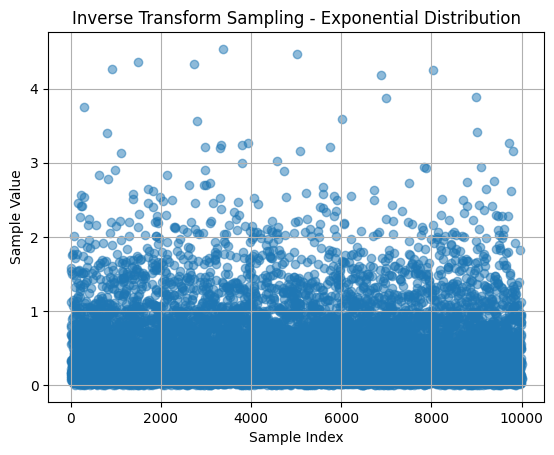

In [52]:
# scatter plot of samples
plt.scatter(range(n), samples, alpha=0.5)
plt.title('Inverse Transform Sampling - Exponential Distribution')  
plt.xlabel('Sample Index')
plt.ylabel('Sample Value')
plt.grid()
plt.show()

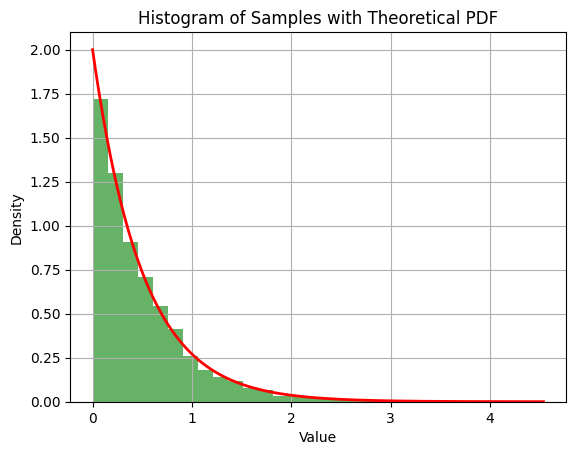

In [53]:
# plot the histogram of samples
plt.hist(samples, bins=30, density=True, alpha=0.6, color='g')
# plot the theoretical pdf of exponential distribution
x = np.linspace(0, max(samples), 1000)
pdf = exponential_distribution(parameter, x)
plt.plot(x, pdf, 'r-', lw=2)
plt.title('Histogram of Samples with Theoretical PDF')
plt.xlabel('Value')
plt.ylabel('Density')       
plt.grid()
plt.show()

# this graph shows that the samples generated using inverse transform sampling closely follow the theoretical exponential distribution, confirming the correctness of our sampling method.

# Discrete Case
lets say we have a discrete distribution with the following PMF:

P(X = x) = {
    0.1, if x = 1
    0.2, if x = 2
    0.3, if x = 3
    0.4, if x = 4
}


In [ ]:
p_x = [0.1, 0.2, 0.3, 0.4]
x_values = [1, 2, 3, 4]
# compute the cumulative distribution function (CDF)
cdf = np.cumsum(p_x)
print(f"CDF: {cdf}")

CDF: [0.1 0.3 0.6 1. ]


Inverse CDF for discrete case is defined as: 

In terms, it is the smallest value of x such that the CDF at that point is greater than or equal to u. Mathematically, it can be expressed as:
$$
F^{-1}(u)=\min\{x\mid F(x)\geq u\}.
$$



In [ ]:
def inverse_cdf_discrete(p_x, x_values, p):
    assert (p > 0 and p < 1)
    cdf = np.cumsum(p_x)
    idx = np.searchsorted(cdf, p) # this can be done using binary search as well, but numpy provides this function which is optimized for performance
    return x_values[idx]
# Example usage
p = 0.2
sampled_value = inverse_cdf_discrete(p_x, x_values, p)
print(f"Sampled value for p={p}: {sampled_value}")

Sampled value for p=0.2: 2


In [67]:
# sample 10 samples from the discrete distribution
discrete_samples = []
for _ in range(20):
    p = np.random.uniform(0, 1)
    sampled_value = inverse_cdf_discrete(p_x, x_values, p)
    discrete_samples.append(sampled_value)
print(f"Discrete samples: {discrete_samples}")



Discrete samples: [3, 3, 4, 3, 4, 4, 1, 1, 3, 4, 3, 4, 3, 1, 3, 3, 2, 4, 4, 3]


In [68]:
mean_discrete = np.mean(discrete_samples)
variance_discrete = np.var(discrete_samples)

print(f"Mean of discrete samples: {mean_discrete}")
print(f"Variance of discrete samples: {variance_discrete}")

# true
mean_true_discrete = np.sum(np.array(x_values) * np.array(p_x))
variance_true_discrete = np.sum(np.array(x_values)**2 * np.array(p_x))  - mean_true_discrete**2

print(f"True mean, True var: {mean_true_discrete}, {variance_true_discrete} ")


Mean of discrete samples: 3.0
Variance of discrete samples: 1.0
True mean, True var: 3.0, 1.0 
